In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv("C:/Users/anton/OneDrive/Documentos/limpieza/dataset_terminado.csv")

df.head()

,Mes,SemanaDelMes,DiaDeLaSemana,MarcaVehiculo,AreaAccidente,DiaReclamo,MesReclamo,SemanaReclamo,Genero,EstadoCivil,...,EdadVehiculo,EdadAsegurado,ReportePolicial,TestigoPresente,TipoAgente,NumeroSuplementos,CambioDireccionReclamo,NumeroVehiculos,Año,PolizaBase
0,Enero,3.0,Miércoles,Honda,Urbano,Monday,Jan,4.0,Masculino,Soltero,...,6 years,31 to 35,Sí,No,External,none,no change,1 vehicle,1994.0,Collision
1,Noviembre,1.0,Viernes,Honda,Urbano,Tuesday,Mar,4.0,Masculino,Soltero,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994.0,Collision
2,Abril,3.0,Martes,Ford,Urbano,Wednesday,Apr,3.0,Masculino,Casado,...,more than 7,36 to 40,No,No,External,3 to 5,no change,1 vehicle,1994.0,All Perils
3,Enero,3.0,Viernes,Ford,Urbano,Friday,Jan,3.0,Masculino,Casado,...,7 years,31 to 35,No,No,External,none,no change,1 vehicle,1994.0,Liability
4,Agosto,4.0,Martes,Ford,Urbano,Monday,Aug,5.0,Masculino,Soltero,...,6 years,36 to 40,No,No,External,none,no change,1 vehicle,1994.0,Liability


In [18]:
print(df.shape) 
df.info()       # Muestra tipos de datos

(4783, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4783 entries, 0 to 4782
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Mes                       4783 non-null   object 
 1   SemanaDelMes              4783 non-null   float64
 2   DiaDeLaSemana             4783 non-null   object 
 3   MarcaVehiculo             4783 non-null   object 
 4   AreaAccidente             4783 non-null   object 
 5   DiaReclamo                4783 non-null   object 
 6   MesReclamo                4783 non-null   object 
 7   SemanaReclamo             4783 non-null   float64
 8   Genero                    4783 non-null   object 
 9   EstadoCivil               4783 non-null   object 
 10  Edad                      4783 non-null   float64
 11  Culpa                     4783 non-null   object 
 12  TipoPoliza                4783 non-null   object 
 13  CategoriaVehiculo         4783 non-null   object 
 1

In [19]:
print("Análisis de Calidad de Datos")

duplicados = df.duplicated().sum()
print(f"Cantidad de filas duplicadas encontradas: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print("Duplicados eliminados.")
else:
    print("No se encontraron duplicados.")

nulos = df.isnull().sum()
print("\nValores nulos por columna:")
print(nulos[nulos > 0]) # Solo muestra las que tienen nulos.

Análisis de Calidad de Datos
Cantidad de filas duplicadas encontradas: 0
No se encontraron duplicados.

Valores nulos por columna:
Series([], dtype: int64)


In [20]:
print(df.describe()) # Para numéricas

print(df['FraudeDetectado'].value_counts()) 
print(df['MarcaVehiculo'].value_counts())

       SemanaDelMes  SemanaReclamo         Edad  FraudeDetectado  \
count   4783.000000    4783.000000  4783.000000      4783.000000   
mean       2.781936       2.708133    39.844031         0.056659   
std        1.292901       1.258892    13.494826         0.231214   
min        1.000000       1.000000     0.000000         0.000000   
25%        2.000000       2.000000    30.000000         0.000000   
50%        3.000000       3.000000    38.000000         0.000000   
75%        4.000000       4.000000    48.000000         0.000000   
max        5.000000       5.000000    80.000000         1.000000   

       NumeroPoliza  NumeroRepresentante    Deducible  CalificacionConductor  \
count    4783.00000          4783.000000  4783.000000            4783.000000   
mean     7795.45369             8.473134   407.024880               2.507004   
std      4450.29266             4.553513    42.417445               1.116913   
min         2.00000             1.000000   300.000000              

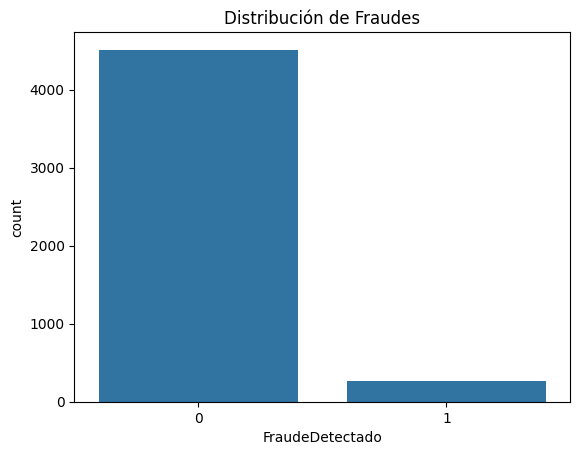

In [21]:
sns.countplot(x='FraudeDetectado', data=df)
plt.title('Distribución de Fraudes')
plt.show()

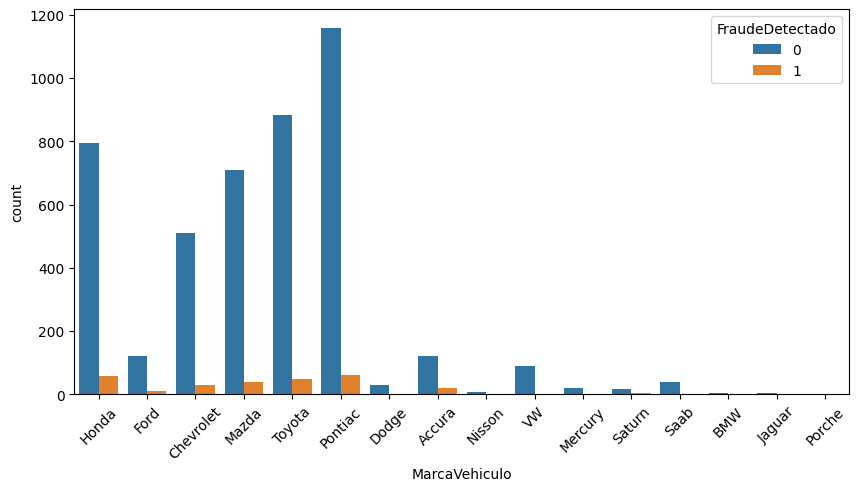

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(x='MarcaVehiculo', hue='FraudeDetectado', data=df)
plt.xticks(rotation=45)
plt.show()

In [23]:
cat_cols = df.select_dtypes(include=['object']).columns
print(f"Columnas de texto detectadas: {list(cat_cols)}")

le = LabelEncoder()

for col in cat_cols:
  
    df[col] = df[col].astype(str)
  
    df[col] = le.fit_transform(df[col])

print("\n¡Transformación completada! Ahora todo el dataset es numérico.")
df.head()

Columnas de texto detectadas: ['Mes', 'DiaDeLaSemana', 'MarcaVehiculo', 'AreaAccidente', 'DiaReclamo', 'MesReclamo', 'Genero', 'EstadoCivil', 'Culpa', 'TipoPoliza', 'CategoriaVehiculo', 'PrecioVehiculo', 'DiasPolizaAccidente', 'DiasPolizaReclamo', 'NumeroReclamosAnteriores', 'EdadVehiculo', 'EdadAsegurado', 'ReportePolicial', 'TestigoPresente', 'TipoAgente', 'NumeroSuplementos', 'CambioDireccionReclamo', 'NumeroVehiculos', 'PolizaBase']

¡Transformación completada! Ahora todo el dataset es numérico.


,Mes,SemanaDelMes,DiaDeLaSemana,MarcaVehiculo,AreaAccidente,DiaReclamo,MesReclamo,SemanaReclamo,Genero,EstadoCivil,...,EdadVehiculo,EdadAsegurado,ReportePolicial,TestigoPresente,TipoAgente,NumeroSuplementos,CambioDireccionReclamo,NumeroVehiculos,Año,PolizaBase
0,3,3.0,4,5,1,1,4,4.0,1,2,...,4,4,1,0,0,3,3,0,1994.0,1
1,9,1.0,6,5,1,5,7,4.0,1,2,...,7,0,0,0,0,3,3,0,1994.0,1
2,0,3.0,3,4,1,6,0,3.0,1,0,...,6,5,0,0,0,1,3,0,1994.0,0
3,3,3.0,6,4,1,0,4,3.0,1,0,...,5,4,0,0,0,3,3,0,1994.0,2
4,1,4.0,3,4,1,1,1,5.0,1,2,...,4,5,0,0,0,3,3,0,1994.0,2


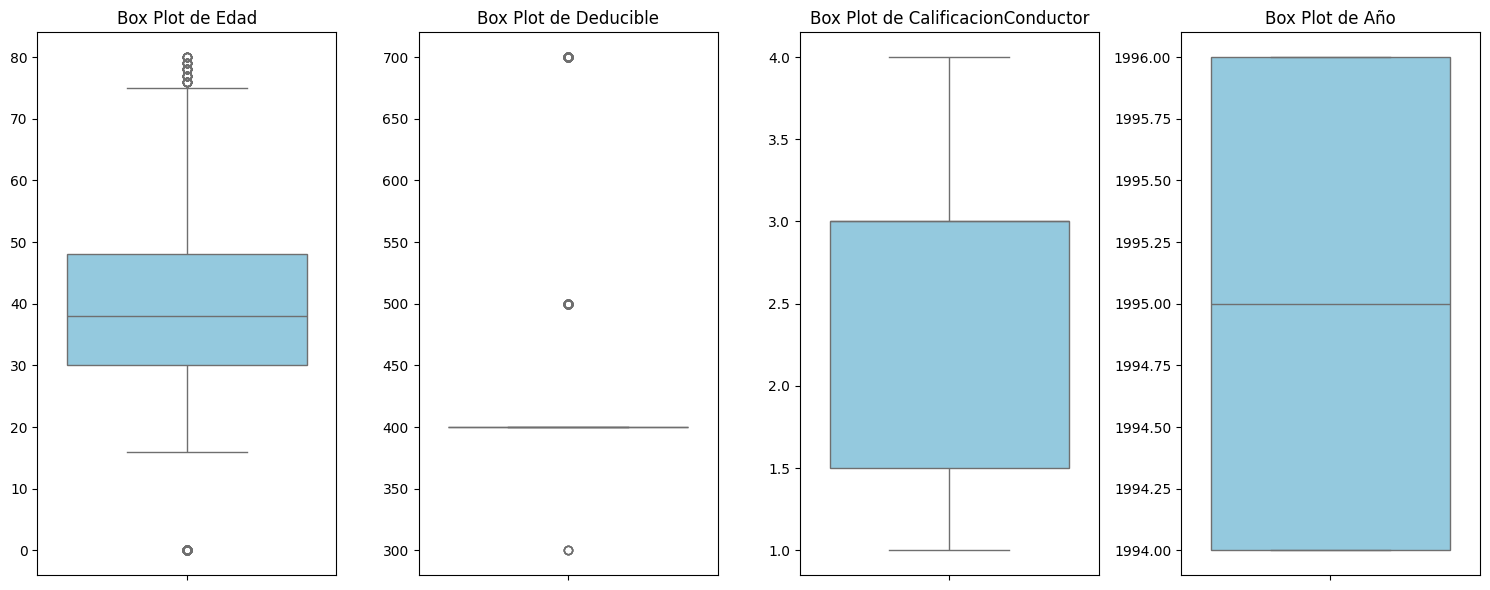

Gráficas Box Plot generadas. Los puntos fuera de las líneas son los Outliers (Valores Atípicos).


In [24]:
columnas_a_revisar = ['Edad', 'Deducible', 'CalificacionConductor', 'Año'] 


for col in columnas_a_revisar:

    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

plt.figure(figsize=(15, 6))

for i, col in enumerate(columnas_a_revisar):
   
    plt.subplot(1, len(columnas_a_revisar), i + 1) 
    
   
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Box Plot de {col}', fontsize=12)
    plt.ylabel('') 

plt.tight_layout()
plt.show()

print("Gráficas Box Plot generadas. Los puntos fuera de las líneas son los Outliers (Valores Atípicos).")

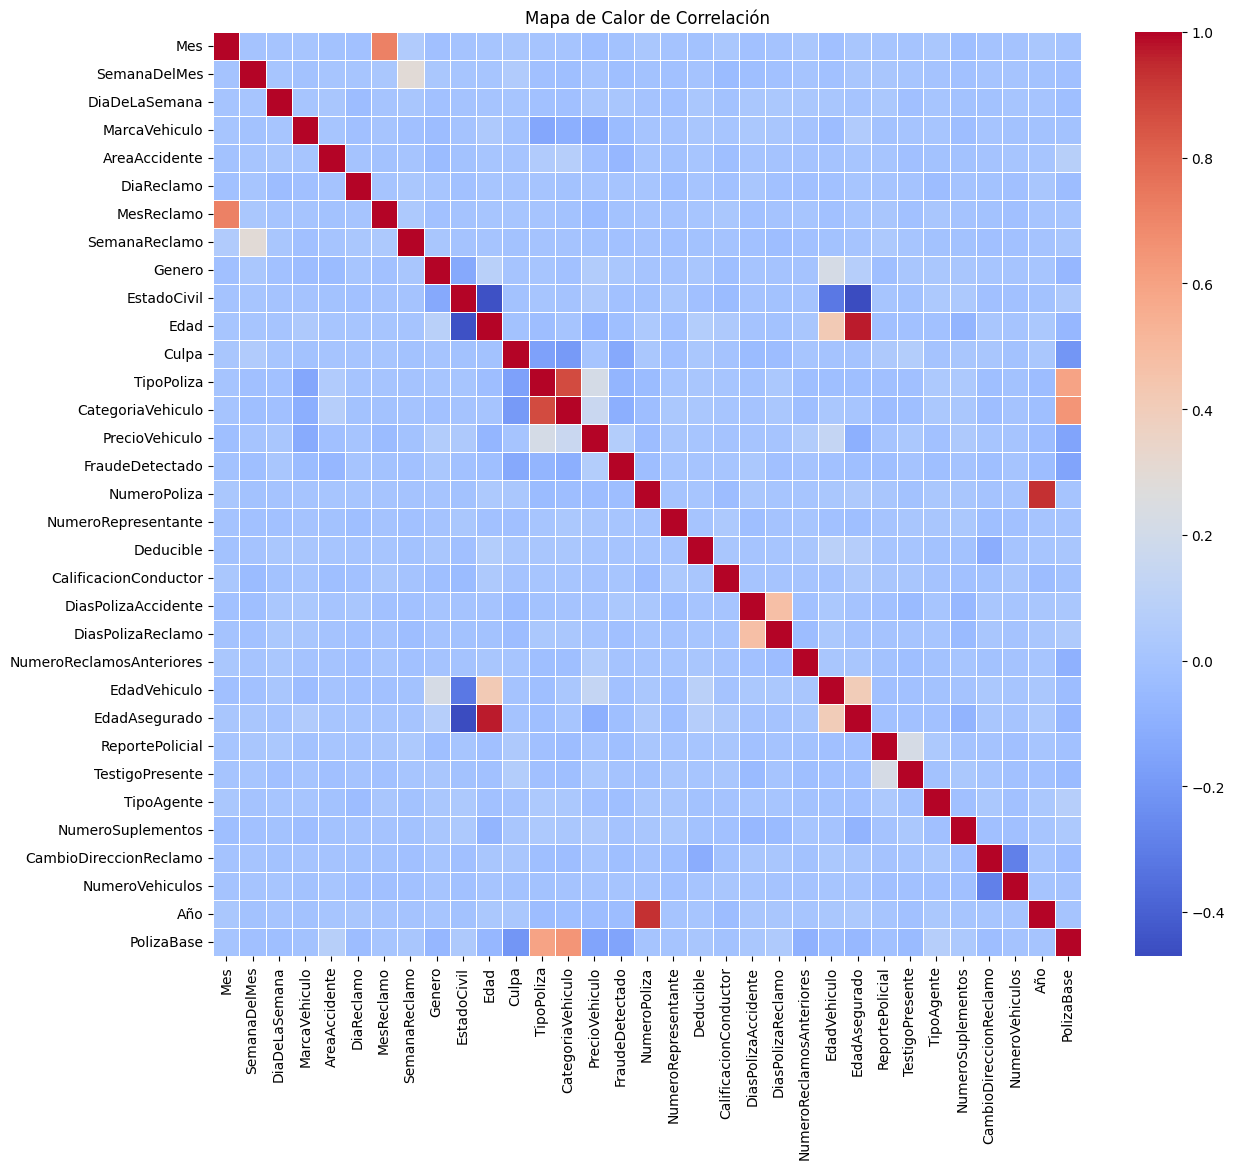

In [25]:
plt.figure(figsize=(14,12))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor de Correlación')
plt.show()

In [26]:

target = 'FraudeDetectado'
X = df.drop(target, axis=1)
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Entrenando modelo..")
model.fit(X_train, y_train)
print("Modelo entrenado!")

Entrenando modelo..
Modelo entrenado!


In [27]:
# Aqio hacemos las predicciones
y_pred = model.predict(X_test)

# Matriz de Confusión
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Matriz de Confusión:
[[1345    0]
 [  90    0]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1345
           1       0.00      0.00      0.00        90

    accuracy                           0.94      1435
   macro avg       0.47      0.50      0.48      1435
weighted avg       0.88      0.94      0.91      1435



c:\Users\anton\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\anton\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\anton\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

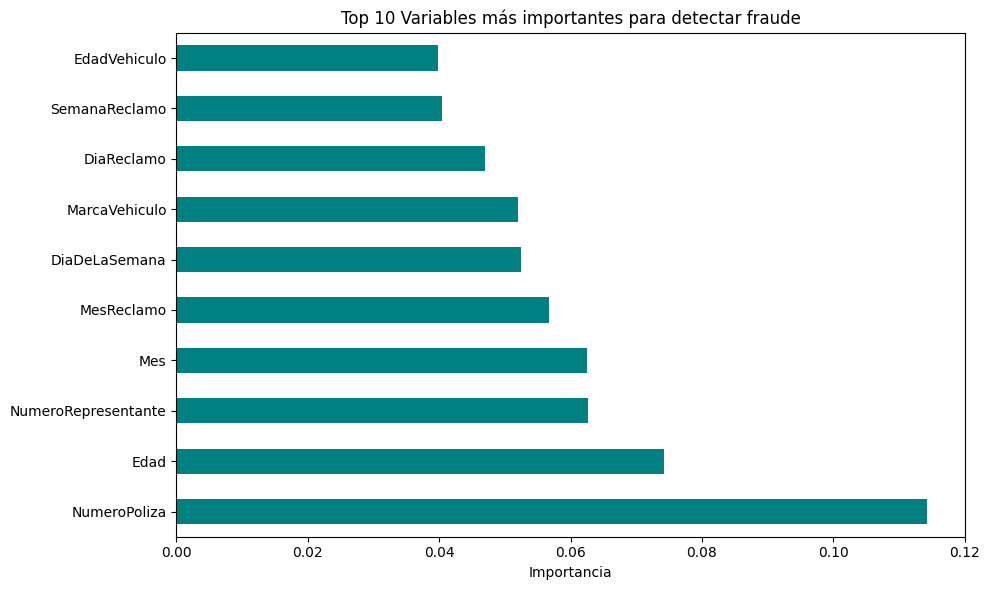

In [28]:
# Ver qué variables influyen más en el fraude
importancias = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 6))
importancias.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Variables más importantes para detectar fraude')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

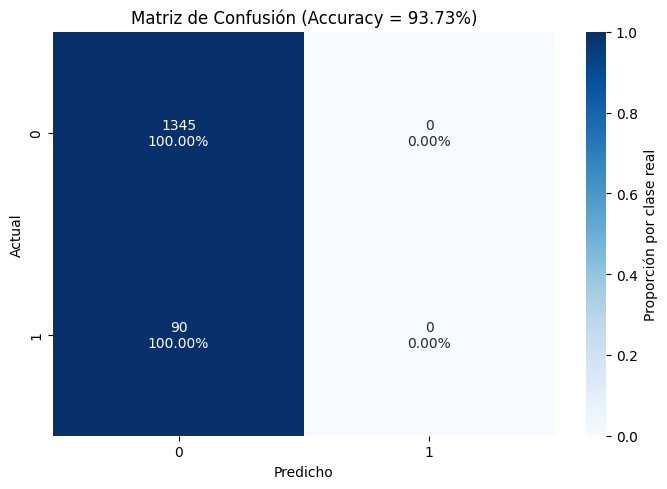

In [29]:
cm = confusion_matrix(y_test, y_pred)
labels = getattr(model, "classes_", np.unique(np.concatenate([y_test, y_pred])))
labels = [str(l) for l in labels]


row_sums = cm.sum(axis=1, keepdims=True)
with np.errstate(divide='ignore', invalid='ignore'):
    cm_norm = cm.astype(float) / row_sums
    cm_norm = np.nan_to_num(cm_norm)

annot = np.empty(cm.shape, dtype=object)     #Es la misma matriz de confusión pero en grafica, lista para ser descargada archivo pjeg
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n{cm_norm[i, j]:.2%}"

plt.figure(figsize=(7,5))
sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Proporción por clase real'})
plt.xlabel('Predicho')
plt.ylabel('Actual')
acc = accuracy_score(y_test, y_pred)
plt.title(f'Matriz de Confusión (Accuracy = {acc:.2%})')
plt.tight_layout()
plt.show()